
--- KẾT QUẢ ADF TEST ---
p-value: 0.0000


15:47:47 - cmdstanpy - INFO - Chain [1] start processing
15:48:06 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


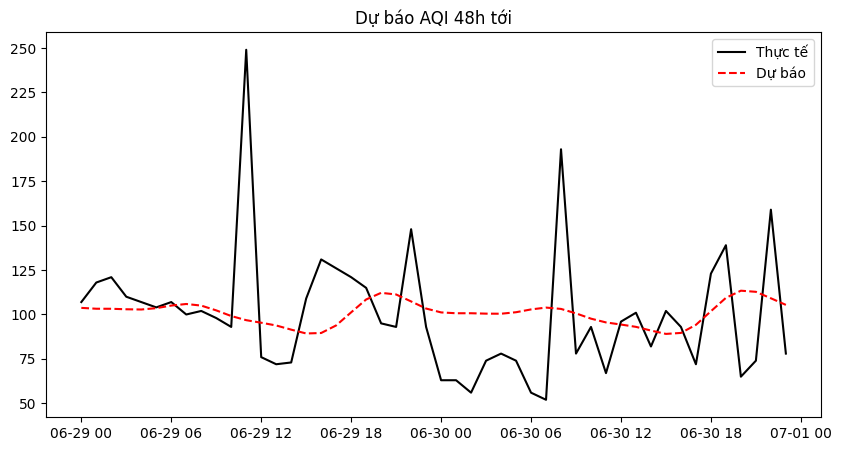


🔍 BÁO CÁO TÍNH CÔNG BẰNG (FAIRNESS REPORT)
RMSE theo Mùa:
season
2    35.764375
dtype: float64


C:\Users\BUI QUANG HUNG\AppData\Local\Temp\ipykernel_11956\136393600.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_season = eval_df.groupby('season').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))


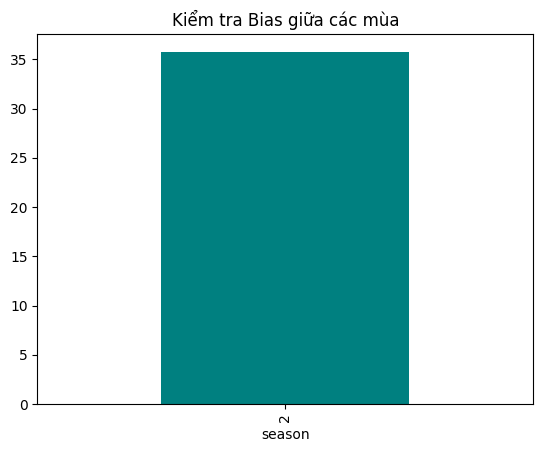

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Xử lý dữ liệu
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
df.columns = df.columns.str.strip().str.lower()
date_col = [c for c in df.columns if 'date' in c or 'time' in c][0]
df = df.rename(columns={date_col: 'datetime'})
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. ADF Test
print("\n--- KẾT QUẢ ADF TEST ---")
result = adfuller(df['aqi'].dropna())
print(f'p-value: {result[1]:.4f}')

# 3. Dự báo Prophet 48h
df_p = df[['datetime', 'aqi']].rename(columns={'datetime': 'ds', 'aqi': 'y'})
train, test = df_p.iloc[:-48], df_p.iloc[-48:]
model = Prophet(daily_seasonality=True, yearly_seasonality=True).fit(train)
forecast = model.predict(model.make_future_dataframe(periods=48, freq='H'))

# Vẽ biểu đồ dự báo
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], test['y'], label='Thực tế', color='black')
plt.plot(forecast['ds'].iloc[-48:], forecast['yhat'].iloc[-48:], label='Dự báo', color='red', ls='--')
plt.title('Dự báo AQI 48h tới')
plt.legend(); plt.show()

# 4. Báo cáo Fairness (Đạo đức AI)
eval_df = test.copy()
eval_df['pred'] = forecast['yhat'].iloc[-48:].values
eval_df['season'] = df['season'].iloc[-48:].values
rmse_season = eval_df.groupby('season').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))

print("\n" + "="*45 + "\n🔍 BÁO CÁO TÍNH CÔNG BẰNG (FAIRNESS REPORT)\n" + "="*45)
print(f"RMSE theo Mùa:\n{rmse_season}")

# Vẽ biểu đồ Bias
rmse_season.plot(kind='bar', color='teal')
plt.title('Kiểm tra Bias giữa các mùa')
plt.show()

# Kết luận Bias tự động
avg_rmse = rmse_season.mean()
for s, r in rmse_season.items():
    if r > avg_rmse * 1.2:
        print(f"⚠️ PHÁT HIỆN BIAS: Model dự báo kém tại mùa {s.upper()}")